
# Minimum Snap Paper QP with OSQP

This notebook is an implementation trial of the QP problem from the minimum snap paper:

**Minimum Snap Trajectory Generation and Control for Quadrotors**  
> Daniel Mellinger and Vijay Kumar, ICRA 2011

Implemented:

- flat outputs: x, y, z, psi
- multiple keyframes
- multiple polynomial segments
- minimum snap cost for position
- second derivative cost for yaw
- waypoint constraints
- boundary derivative constraints
- continuity constraints
- OSQP standard form
- residual check
- visual diagnostics


Not Implemented:

- corridor constraints
- input / velocity / acceleration inequality limits
- segment time optimization
- differential flatness map to thrust and moments
- nonlinear tracking controller

So:

> core trajectory-generation QP from the paper but without corridor constraints and time optimization.

---


## 1. Background

Paper uses quadrotor flat outputs:

$$
\sigma(t)
=
\begin{bmatrix}
x(t) \\
y(t) \\
z(t) \\
\psi(t)
\end{bmatrix}
$$

where:

- x,y,z are position in the world frame
- psi is yaw angle

Paper writes trajectory as a piecewise polynomial through keyframes.

For position, paper minimizes squared norm of snap:

$$
\int
\left\|
\frac{d^4 r_T(t)}{dt^4}
\right\|^2
dt
$$

For yaw, the second derivative:

$$
\int
\left(
\frac{d^2 \psi_T(t)}{dt^2}
\right)^2
dt
$$

The resulting optimization problem can be written as a QP over polynomial coefficients.

---


## 2. OSQP Form

OSQP solves QP problems in the form:

$$
\min_c \frac{1}{2}c^T P c + q^T c
$$

subject to:

$$
l \leq A c \leq u
$$

In this notebook:

- "c" is the vector of all polynomial coefficients
- "P" is the quadratic cost matrix
- "q=0", because there is no linear cost term
- "A,l,u" represent waypoint, boundary, and continuity constraints

For equality constraints:

$$
Ac=b
$$

I use:

$$
l=b,\quad u=b
$$

---


## 3. Keyframes

Each keyframe contains:

$$
[x, y, z, \psi]
$$

I use four keyframes, so trajectory has three segments.

Each segment has its own polynomial for each flat output.

---


## 4. Piecewise Polynomial Representation

7th-order polynomial is used:

$$
w_s(\tau)
=
a_{s,0}
+
a_{s,1}\tau
+
a_{s,2}\tau^2
+
\cdots
+
a_{s,7}\tau^7
$$

where:

- w can be x,y,z,\psi
- s is segment index
- tau is local time inside the segment
- a_s,i are polynomial coefficients

Optimizer chooses the polynomial coefficients.

Key points:

> QP does not directly choose trajectory points.  
> It chooses coefficients that define the full trajectory.

---


## 5. Constraints Implemented

### 1. Waypoint constraints

Each segment must start and end at the correct keyframes.

$$
x_s(0)=x_i
$$

$$
x_s(T_s)=x_{i+1}
$$

Same idea is used for y,z,psi.

### 2. Boundary derivative constraints

At the beginning and end of the full trajectory, setted some derivatives to zero.

For position:

$$
\dot{x}=\ddot{x}=\dddot{x}=0
$$

and the same for y,z.

For yaw:

$$
\dot{\psi}=0
$$

at the start and end.

### 3. Continuity constraints

At internal keyframes, neighboring segments should connect smoothly.

For position, derivative continuity up to snap is enforced:

$$
w_s^{(d)}(T_s)=w_{s+1}^{(d)}(0),\quad d=1,2,3,4
$$

For yaw, continuity up to the second derivative is enforced:

$$
\psi_s^{(d)}(T_s)=\psi_{s+1}^{(d)}(0),\quad d=1,2
$$

---


## 6. Cost Implemented

For position outputs \(x,y,z\), I use:

$$
k_r=4
$$

so the cost is minimum snap:

$$
\int_0^{T_s}
\left(
w_s^{(4)}(\tau)
\right)^2
d\tau
$$

For yaw:

$$
k_\psi=2
$$

so cost is:

$$
\int_0^{T_s}
\left(
\psi_s^{(2)}(\tau)
\right)^2
d\tau
$$

Because each derivative is linear in the polynomial coefficients, squared derivative integral becomes quadratic form:

$$
c^T Q c
$$

OSQP uses:

$$
\frac{1}{2}c^TPc
$$

so each cost block uses:

$$
P = 2Q
$$

---

In [ ]:
# - OSQP Python interface: problem setup uses P, q, A, l, u.
# - Standard OSQP form: minimize 1/2 c^T P c + q^T c subject to l <= A c <= u.

import numpy as np
import scipy.sparse as sp
import osqp
import matplotlib.pyplot as plt

print("OSQP version:", osqp.__version__)

OSQP version: 1.1.1


In [ ]:
def derivative_coefficient(power, derivative_order):
    # Coefficient produced by differentiating tau^power derivative_order times.
    if power < derivative_order:
        return 0.0

    coeff = 1.0
    for k in range(derivative_order):
        coeff *= power - k

    return coeff

def derivative_row(tau, degree, derivative_order):
    # row @ coeffs = w^(derivative_order)(tau)
    row = np.zeros(degree + 1)

    for power in range(degree + 1):
        coeff = derivative_coefficient(power, derivative_order)

        if coeff != 0.0:
            row[power] = coeff * (tau ** (power - derivative_order))

    return row

def derivative_cost_matrix(degree, T, derivative_order):
    # integral_0^T (w^(derivative_order)(tau))^2 d tau = c^T Q c
    Q = np.zeros((degree + 1, degree + 1))

    for i in range(degree + 1):
        ci = derivative_coefficient(i, derivative_order)
        if ci == 0.0:
            continue

        for j in range(degree + 1):
            cj = derivative_coefficient(j, derivative_order)
            if cj == 0.0:
                continue

            power = i + j - 2 * derivative_order
            Q[i, j] = ci * cj * (T ** (power + 1)) / (power + 1)

    return Q

def variable_start_index(dim, segment, num_segments, num_coeffs):
    return (dim * num_segments + segment) * num_coeffs

def add_derivative_to_row(row, dim, segment, tau, derivative_order, scale,
                          degree, num_segments, num_coeffs):
    start = variable_start_index(dim, segment, num_segments, num_coeffs)
    local = derivative_row(tau, degree, derivative_order)
    row[start:start + num_coeffs] += scale * local

def evaluate_polynomial(coeffs, tau_values, derivative_order):
    degree = len(coeffs) - 1
    values = np.zeros_like(tau_values, dtype=float)

    for power, a in enumerate(coeffs):
        coeff = derivative_coefficient(power, derivative_order)

        if coeff != 0.0:
            values += a * coeff * (tau_values ** (power - derivative_order))

    return values

In [ ]:
# Keyframes: [x, y, z, yaw]
keyframes = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.5, 0.2],
    [2.0, 0.0, 1.0, -0.2],
    [3.0, 1.0, 1.2, 0.0],
])

segment_times = np.array([1.0, 1.0, 1.0])

flat_output_names = ["x", "y", "z", "psi"]

num_keyframes = keyframes.shape[0]
num_segments = num_keyframes - 1
num_outputs = keyframes.shape[1]

degree = 7
num_coeffs = degree + 1
num_variables = num_outputs * num_segments * num_coeffs

print("Keyframes:")
print(keyframes)

print()
print("Number of keyframes:", num_keyframes)
print("Number of segments:", num_segments)
print("Flat outputs:", flat_output_names)
print("Polynomial degree:", degree)
print("Coefficients per segment:", num_coeffs)
print("Total decision variables:", num_variables)

Keyframes:
[[ 0.   0.   0.   0. ]
 [ 1.   1.   0.5  0.2]
 [ 2.   0.   1.  -0.2]
 [ 3.   1.   1.2  0. ]]

Number of keyframes: 4
Number of segments: 3
Flat outputs: ['x', 'y', 'z', 'psi']
Polynomial degree: 7
Coefficients per segment: 8
Total decision variables: 96


---

## 7. Build Cost Matrix

The cost is block diagonal because each output and each segment has its own polynomial cost.

For x,y,z:

$$
\text{derivative order}=4
$$

For psi:

$$
\text{derivative order}=2
$$

In [ ]:
#  x, y, z use k_r = 4 (snap).
#  psi uses k_psi = 2.
cost_derivative_orders = [4, 4, 4, 2]

# simple demonstration weights
cost_weights = [1.0, 1.0, 1.0, 0.2]

P_dense = np.zeros((num_variables, num_variables))
q = np.zeros(num_variables)

for dim in range(num_outputs):
    derivative_order = cost_derivative_orders[dim]
    weight = cost_weights[dim]

    for segment in range(num_segments):
        T = segment_times[segment]

        Q_seg = derivative_cost_matrix(
            degree=degree,
            T=T,
            derivative_order=derivative_order,
        )

        start = variable_start_index(dim, segment, num_segments, num_coeffs)
        end = start + num_coeffs

        # OSQP : 1/2 c^T P c.
        # derivative integral : c^T Q c.
        P_dense[start:end, start:end] = 2.0 * weight * Q_seg

# Numerical regularization.
regularization = 1e-9
P_dense += regularization * np.eye(num_variables)

P = sp.csc_matrix(P_dense)

print("P shape:", P.shape)
print("q shape:", q.shape)
print("P nonzeros:", P.nnz)

P shape: (96, 96)
q shape: (96,)
P nonzeros: 294


---

## 8. Build Constraint Matrix

Equality constraints:

$$
Ac=b
$$

Then use OSQP bounds:

$$
l=b,\quad u=b
$$

The labels are stored so I can inspect which constraint has the largest residual.

In [ ]:

# paper states that endpoint derivatives can be specified as zero or left free.
# paper enforces derivative continuity at internal keyframes.

rows = []
bounds = []
labels = []

def add_equality(row, value, label):
    rows.append(row.copy())
    bounds.append(float(value))
    labels.append(label)

# CONSTRAINTS
# 1. Waypoint constraints
for dim, name in enumerate(flat_output_names):
    for segment in range(num_segments):
        T = segment_times[segment]

        # Start of segment
        row = np.zeros(num_variables)
        add_derivative_to_row(
            row=row,
            dim=dim,
            segment=segment,
            tau=0.0,
            derivative_order=0,
            scale=1.0,
            degree=degree,
            num_segments=num_segments,
            num_coeffs=num_coeffs,
        )
        add_equality(row, keyframes[segment, dim], f"{name}: segment {segment} start waypoint")

        # End of segment
        row = np.zeros(num_variables)
        add_derivative_to_row(
            row=row,
            dim=dim,
            segment=segment,
            tau=T,
            derivative_order=0,
            scale=1.0,
            degree=degree,
            num_segments=num_segments,
            num_coeffs=num_coeffs,
        )
        add_equality(row, keyframes[segment + 1, dim], f"{name}: segment {segment} end waypoint")


# 2. Boundary derivative constraints
# - position, velocity, acceleration, and jerk : set to zero at full start and full end.
# - yaw : set to zero at full start and full end.
boundary_derivatives = {
    0: [1, 2, 3],
    1: [1, 2, 3],
    2: [1, 2, 3],
    3: [1],
}

for dim, name in enumerate(flat_output_names):
    for derivative_order in boundary_derivatives[dim]:

        # Start boundary
        row = np.zeros(num_variables)
        add_derivative_to_row(
            row=row,
            dim=dim,
            segment=0,
            tau=0.0,
            derivative_order=derivative_order,
            scale=1.0,
            degree=degree,
            num_segments=num_segments,
            num_coeffs=num_coeffs,
        )
        add_equality(row, 0.0, f"{name}: derivative {derivative_order} at trajectory start")

        # End boundary
        row = np.zeros(num_variables)
        add_derivative_to_row(
            row=row,
            dim=dim,
            segment=num_segments - 1,
            tau=segment_times[-1],
            derivative_order=derivative_order,
            scale=1.0,
            degree=degree,
            num_segments=num_segments,
            num_coeffs=num_coeffs,
        )
        add_equality(row, 0.0, f"{name}: derivative {derivative_order} at trajectory end")


# 3. Continuity constraints
# position, continuity of velocity, acceleration, jerk, and snap : enforced.
# yaw : continuity of yaw rate and yaw acceleration is enforced.
continuity_derivatives = {
    0: [1, 2, 3, 4],
    1: [1, 2, 3, 4],
    2: [1, 2, 3, 4],
    3: [1, 2],
}

for dim, name in enumerate(flat_output_names):
    for segment in range(num_segments - 1):
        T = segment_times[segment]

        for derivative_order in continuity_derivatives[dim]:
            row = np.zeros(num_variables)

            # End of current segment
            add_derivative_to_row(
                row=row,
                dim=dim,
                segment=segment,
                tau=T,
                derivative_order=derivative_order,
                scale=1.0,
                degree=degree,
                num_segments=num_segments,
                num_coeffs=num_coeffs,
            )

            # Start of next segment
            add_derivative_to_row(
                row=row,
                dim=dim,
                segment=segment + 1,
                tau=0.0,
                derivative_order=derivative_order,
                scale=-1.0,
                degree=degree,
                num_segments=num_segments,
                num_coeffs=num_coeffs,
            )

            add_equality(
                row,
                0.0,
                f"{name}: derivative {derivative_order} continuity between segment {segment} and {segment+1}",
            )


A = sp.csc_matrix(np.vstack(rows))
b = np.array(bounds)

l = b.copy()
u = b.copy()

print("A shape:", A.shape)
print("Number of equality constraints:", len(b))
print("l shape:", l.shape)
print("u shape:", u.shape)

print()
print("First 15 constraints:")
for label in labels[:15]:
    print("-", label)

A shape: (72, 96)
Number of equality constraints: 72
l shape: (72,)
u shape: (72,)

First 15 constraints:
- x: segment 0 start waypoint
- x: segment 0 end waypoint
- x: segment 1 start waypoint
- x: segment 1 end waypoint
- x: segment 2 start waypoint
- x: segment 2 end waypoint
- y: segment 0 start waypoint
- y: segment 0 end waypoint
- y: segment 1 start waypoint
- y: segment 1 end waypoint
- y: segment 2 start waypoint
- y: segment 2 end waypoint
- z: segment 0 start waypoint
- z: segment 0 end waypoint
- z: segment 1 start waypoint


---

## 9. Solve QP with OSQP

Since QP is ready, solution vector c^* contains all polynomial coefficients for all flat outputs and all segments.

In [ ]:
solver = osqp.OSQP()

solver.setup(
    P=P,
    q=q,
    A=A,
    l=l,
    u=u,
    verbose=False,
    polish=True,
    eps_abs=1e-5,
    eps_rel=1e-5,
    max_iter=200000,
)

result = solver.solve()

print("Status:", result.info.status)
print("Objective value:", result.info.obj_val)

if result.info.status not in ["solved", "solved inaccurate"]:
    raise RuntimeError(f"OSQP did not solve the QP successfully: {result.info.status}")

c_star = result.x
print("Solution vector shape:", c_star.shape)

Status: solved
Objective value: 33376.918874974486
Solution vector shape: (96,)


---

## 10. Verify Constraints

Should check:

$$
Ac^* - b
$$

and this tells whether waypoint, boundary, and continuity constraints are actually satisfied.

In [ ]:
constraint_values = A @ c_star
residual = constraint_values - b
abs_residual = np.abs(residual)

print("Maximum absolute residual:", np.max(abs_residual))
print("Mean absolute residual:", np.mean(abs_residual))

print()
print("Largest residual constraints:")
largest_indices = np.argsort(-abs_residual)[:12]

for idx in largest_indices:
    print(f"{idx:3d} | residual = {residual[idx]: .3e} | {labels[idx]}")

Maximum absolute residual: 2.9340853258119637e-07
Mean absolute residual: 2.936645956309272e-08

Largest residual constraints:
 33 | residual = -2.934e-07 | y: derivative 2 at trajectory end
 31 | residual =  2.350e-07 | y: derivative 1 at trajectory end
 27 | residual = -1.751e-07 | x: derivative 2 at trajectory end
 25 | residual =  1.403e-07 | x: derivative 1 at trajectory end
 10 | residual =  8.816e-08 | y: segment 2 start waypoint
 11 | residual = -8.815e-08 | y: segment 2 end waypoint
 56 | residual = -7.201e-08 | y: derivative 1 continuity between segment 1 and 2
  7 | residual = -6.511e-08 | y: segment 0 end waypoint
  6 | residual =  6.511e-08 | y: segment 0 start waypoint
  4 | residual =  5.262e-08 | x: segment 2 start waypoint
  5 | residual = -5.260e-08 | x: segment 2 end waypoint
 30 | residual =  4.707e-08 | y: derivative 1 at trajectory start


In [8]:

def get_coefficients(solution, dim, segment):
    start = variable_start_index(dim, segment, num_segments, num_coeffs)
    end = start + num_coeffs
    return solution[start:end]


def evaluate_piecewise(solution, dim, derivative_order, samples_per_segment=120):
    global_times = []
    values = []

    time_offset = 0.0

    for segment in range(num_segments):
        T = segment_times[segment]

        tau_values = np.linspace(0.0, T, samples_per_segment)

        if segment > 0:
            tau_values = tau_values[1:]

        coeffs = get_coefficients(solution, dim, segment)
        segment_values = evaluate_polynomial(coeffs, tau_values, derivative_order)

        global_times.extend(time_offset + tau_values)
        values.extend(segment_values)

        time_offset += T

    return np.array(global_times), np.array(values)


t_plot, x_plot = evaluate_piecewise(c_star, dim=0, derivative_order=0)
_, y_plot = evaluate_piecewise(c_star, dim=1, derivative_order=0)
_, z_plot = evaluate_piecewise(c_star, dim=2, derivative_order=0)
_, yaw_plot = evaluate_piecewise(c_star, dim=3, derivative_order=0)

_, vx_plot = evaluate_piecewise(c_star, dim=0, derivative_order=1)
_, vy_plot = evaluate_piecewise(c_star, dim=1, derivative_order=1)
_, vz_plot = evaluate_piecewise(c_star, dim=2, derivative_order=1)

_, ax_plot = evaluate_piecewise(c_star, dim=0, derivative_order=2)
_, ay_plot = evaluate_piecewise(c_star, dim=1, derivative_order=2)
_, az_plot = evaluate_piecewise(c_star, dim=2, derivative_order=2)

_, jx_plot = evaluate_piecewise(c_star, dim=0, derivative_order=3)
_, jy_plot = evaluate_piecewise(c_star, dim=1, derivative_order=3)
_, jz_plot = evaluate_piecewise(c_star, dim=2, derivative_order=3)

_, sx_plot = evaluate_piecewise(c_star, dim=0, derivative_order=4)
_, sy_plot = evaluate_piecewise(c_star, dim=1, derivative_order=4)
_, sz_plot = evaluate_piecewise(c_star, dim=2, derivative_order=4)

_, yaw_rate_plot = evaluate_piecewise(c_star, dim=3, derivative_order=1)
_, yaw_acc_plot = evaluate_piecewise(c_star, dim=3, derivative_order=2)



## 11. Visual Diagnostics

I check:

1. 3D trajectory through keyframes
2. position components
3. velocity components
4. acceleration components
5. jerk components
6. snap components
7. yaw, yaw rate, and yaw acceleration

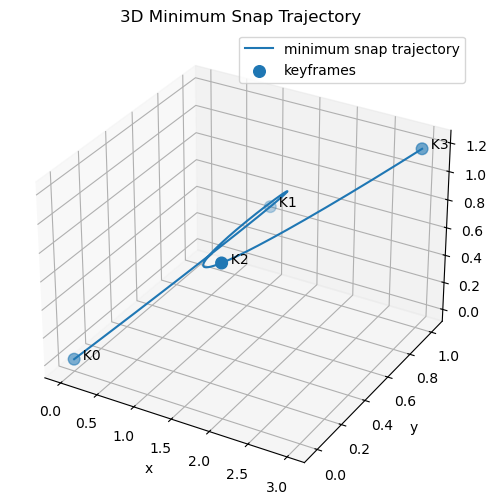

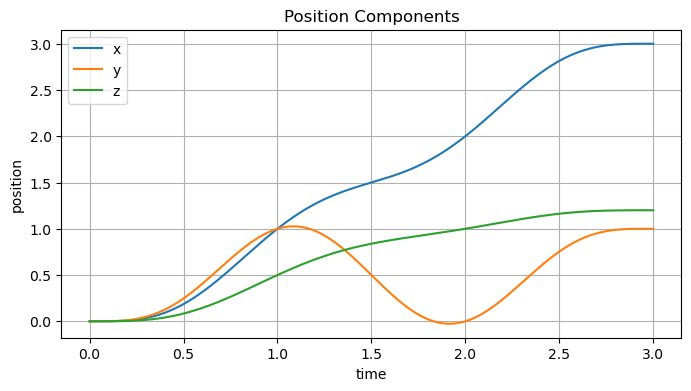

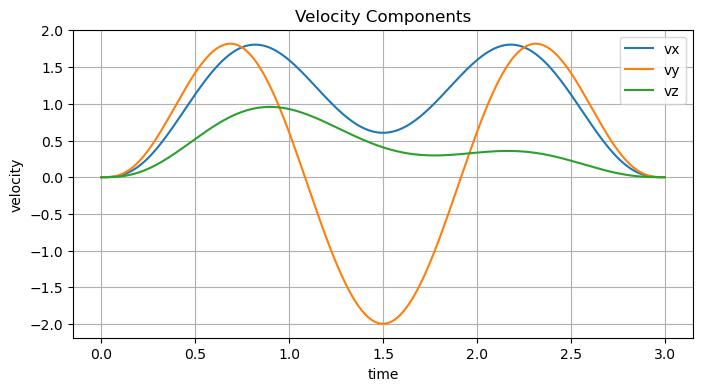

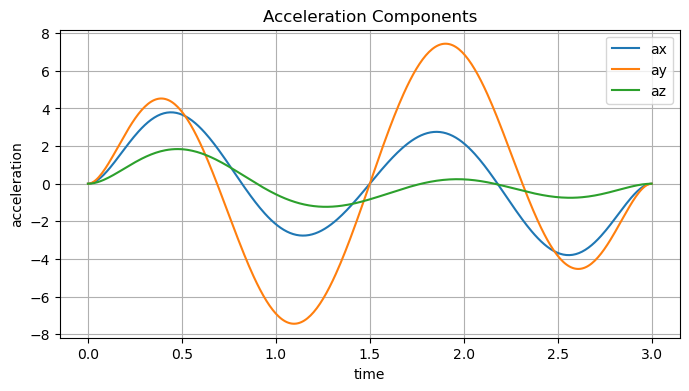

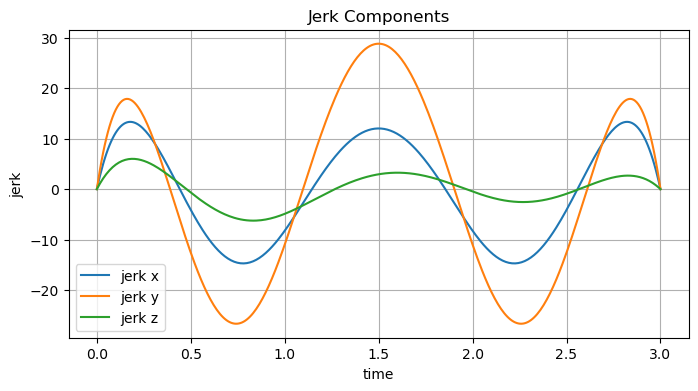

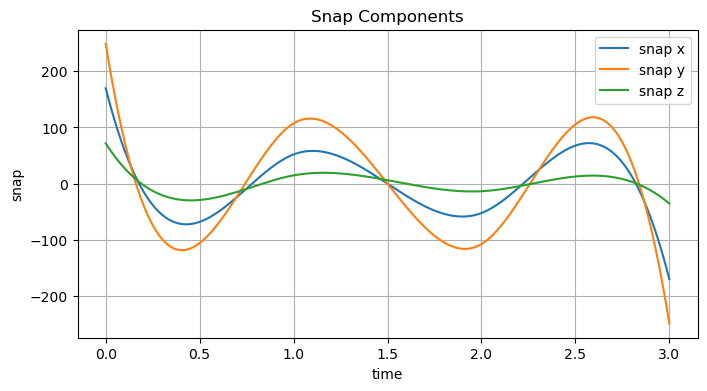

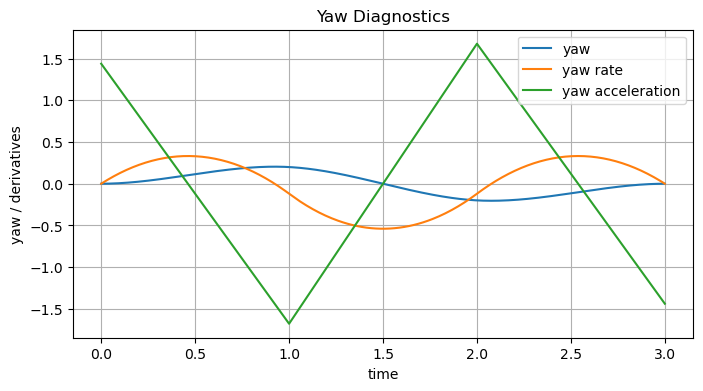

In [ ]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x_plot, y_plot, z_plot, label="minimum snap trajectory")
ax.scatter(keyframes[:, 0], keyframes[:, 1], keyframes[:, 2], s=70, label="keyframes")

for i, point in enumerate(keyframes):
    ax.text(point[0], point[1], point[2], f"  K{i}")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D Minimum Snap Trajectory")
ax.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, x_plot, label="x")
plt.plot(t_plot, y_plot, label="y")
plt.plot(t_plot, z_plot, label="z")
plt.xlabel("time")
plt.ylabel("position")
plt.title("Position Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, vx_plot, label="vx")
plt.plot(t_plot, vy_plot, label="vy")
plt.plot(t_plot, vz_plot, label="vz")
plt.xlabel("time")
plt.ylabel("velocity")
plt.title("Velocity Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, ax_plot, label="ax")
plt.plot(t_plot, ay_plot, label="ay")
plt.plot(t_plot, az_plot, label="az")
plt.xlabel("time")
plt.ylabel("acceleration")
plt.title("Acceleration Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, jx_plot, label="jerk x")
plt.plot(t_plot, jy_plot, label="jerk y")
plt.plot(t_plot, jz_plot, label="jerk z")
plt.xlabel("time")
plt.ylabel("jerk")
plt.title("Jerk Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, sx_plot, label="snap x")
plt.plot(t_plot, sy_plot, label="snap y")
plt.plot(t_plot, sz_plot, label="snap z")
plt.xlabel("time")
plt.ylabel("snap")
plt.title("Snap Components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_plot, yaw_plot, label="yaw")
plt.plot(t_plot, yaw_rate_plot, label="yaw rate")
plt.plot(t_plot, yaw_acc_plot, label="yaw acceleration")
plt.xlabel("time")
plt.ylabel("yaw / derivatives")
plt.title("Yaw Diagnostics")
plt.grid(True)
plt.legend()
plt.show()
